# Interest Rate Instruments Pricing Tutorial

This tutorial demonstrates how to price interest rate derivatives in QuantStrata, covering:

1. **Linear Instruments**: Forward Rate Agreements (FRAs) and Interest Rate Swaps (IRS)
2. **Options on Rates**: Caps, Floors, and Swaptions
3. **Greeks Analysis**: DV01, delta, vega for rate products
4. **Model Comparison**: Black76 vs Bachelier models

## Setup

In [3]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt

# QuantStrata imports
from src.instruments.ir import (
    ForwardRateAgreementSimple,
    InterestRateSwapSimple,
    CapletSimple,
    CapSimple,
    FloorletSimple,
)
from src.instruments.ir.options.swaption import SwaptionSimple
from src.instruments.ir.linear.swap import FixedLeg, FloatingLeg

from src.pricers.ir import (
    FRAPricerSimple,
    IRSwapPricerSimple,
    IrEuropeanCapletB76PricerSimple,
    IrEuropeanCapB76PricerSimple,
    IrEuropeanFloorletB76PricerSimple,
    IrEuropeanSwaptionBchPricerSimple,
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("QuantStrata IR Instruments loaded successfully!")

QuantStrata IR Instruments loaded successfully!


---

## Part 1: Forward Rate Agreements (FRAs)

A FRA is the simplest interest rate derivative - an agreement to exchange a fixed rate for a floating rate on a notional principal for a single future period.

### 1.1 FRA Pricing Formula

$$PV = N \times \tau \times DF \times (F - K)$$

Where:
- $N$ = notional
- $\tau$ = accrual factor
- $DF$ = discount factor to payment
- $F$ = forward rate
- $K$ = contract rate

In [4]:
# Create a 3x6 FRA (3 months to fixing, 6 months to payment)
fra_3x6 = ForwardRateAgreementSimple(
    notional=10_000_000,
    fixed_rate=0.05,           # 5% contract rate
    fixing_time=0.25,          # 3 months
    payment_time=0.5,          # 6 months
    accrual_factor=0.25,       # Quarterly
    forward_rate=0.052,        # 5.2% forward rate
    discount_factor=0.975,
    direction="payer",         # Pay fixed, receive floating
)

pricer = FRAPricerSimple()

# Price and Greeks
pv = pricer.price(fra_3x6)
greeks = pricer.greeks(fra_3x6)
par_rate = pricer.par_rate(fra_3x6)

print("3x6 FRA Analysis")
print("=" * 40)
print(f"Notional:       ${fra_3x6.notional:,.0f}")
print(f"Contract Rate:  {fra_3x6.fixed_rate:.2%}")
print(f"Forward Rate:   {fra_3x6.forward_rate:.2%}")
print(f"Direction:      {fra_3x6.direction}")
print()
print(f"Present Value:  ${pv:,.2f}")
print(f"Par Rate:       {par_rate:.2%}")
print(f"DV01:           ${greeks['dv01']:,.2f}")
print(f"Delta:          ${greeks['delta']:,.2f}")

3x6 FRA Analysis
Notional:       $10,000,000
Contract Rate:  5.00%
Forward Rate:   5.20%
Direction:      payer

Present Value:  $4,875.00
Par Rate:       5.20%
DV01:           $243.75
Delta:          $2,437,500.00


### 1.2 FRA PV vs Forward Rate

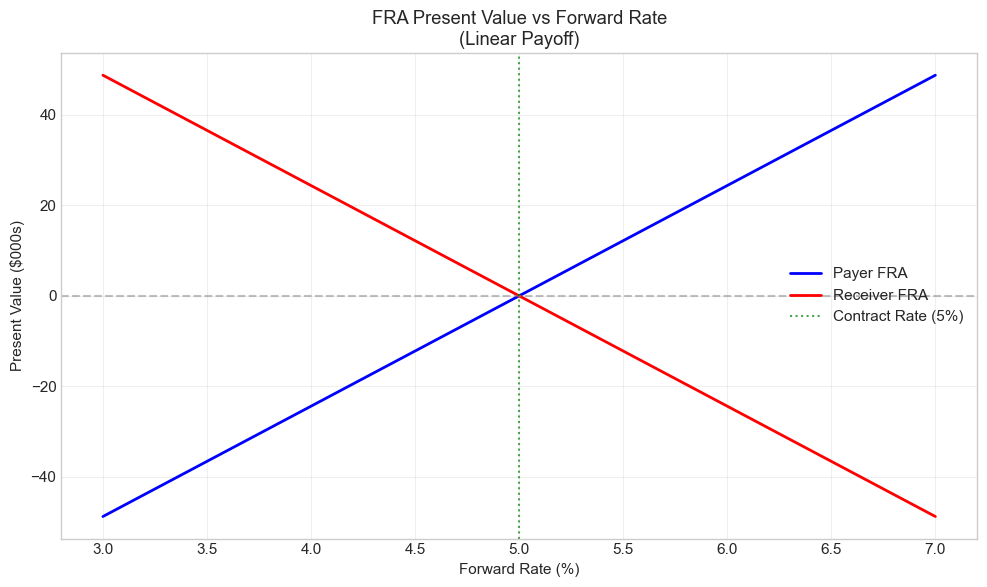

In [5]:
# FRA PV as a function of forward rate
forward_rates = np.linspace(0.03, 0.07, 50)
payer_pvs = []
receiver_pvs = []

for fwd in forward_rates:
    # Payer FRA
    payer = ForwardRateAgreementSimple(
        notional=10_000_000,
        fixed_rate=0.05,
        fixing_time=0.25,
        payment_time=0.5,
        accrual_factor=0.25,
        forward_rate=fwd,
        discount_factor=0.975,
        direction="payer",
    )
    payer_pvs.append(pricer.price(payer))
    
    # Receiver FRA
    receiver = ForwardRateAgreementSimple(
        notional=10_000_000,
        fixed_rate=0.05,
        fixing_time=0.25,
        payment_time=0.5,
        accrual_factor=0.25,
        forward_rate=fwd,
        discount_factor=0.975,
        direction="receiver",
    )
    receiver_pvs.append(pricer.price(receiver))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(forward_rates * 100, np.array(payer_pvs) / 1000, 'b-', linewidth=2, label='Payer FRA')
ax.plot(forward_rates * 100, np.array(receiver_pvs) / 1000, 'r-', linewidth=2, label='Receiver FRA')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=5.0, color='green', linestyle=':', alpha=0.7, label='Contract Rate (5%)')
ax.set_xlabel('Forward Rate (%)')
ax.set_ylabel('Present Value ($000s)')
ax.set_title('FRA Present Value vs Forward Rate\n(Linear Payoff)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 2: Interest Rate Swaps (IRS)

An IRS exchanges fixed rate payments for floating rate payments over multiple periods. It can be viewed as a portfolio of FRAs.

### 2.1 Creating a Swap

In [6]:
# Create a 5-year receiver swap (receive fixed, pay floating)
# Build the legs manually for transparency

# Assume a flat 5% curve
rate = 0.05
notional = 10_000_000
fixed_rate = 0.05  # 5% fixed

# Annual payments for simplicity
fixed_legs = []
floating_legs = []

for i in range(1, 6):  # 5 years
    df = np.exp(-rate * i)  # Discount factor
    fwd = rate + 0.001 * (i - 3)  # Slight term structure
    
    fixed_legs.append(FixedLeg(
        start_time=i-1,
        end_time=i,
        accrual_factor=1.0,
        discount_factor=df,
        notional=notional,
        fixed_rate=fixed_rate,
    ))
    
    floating_legs.append(FloatingLeg(
        start_time=i-1,
        end_time=i,
        accrual_factor=1.0,
        discount_factor=df,
        notional=notional,
        forward_rate=fwd,
    ))

swap = InterestRateSwapSimple(
    notional=notional,
    fixed_rate=fixed_rate,
    fixed_leg=tuple(fixed_legs),
    floating_leg=tuple(floating_legs),
    direction="receiver",
)

swap_pricer = IRSwapPricerSimple()

# Price and analytics
swap_pv = swap_pricer.price(swap)
swap_greeks = swap_pricer.greeks(swap)
par_rate = swap_pricer.par_rate(swap)
fixed_pv = swap_pricer.fixed_leg_pv(swap)
float_pv = swap_pricer.floating_leg_pv(swap)

print("5-Year Interest Rate Swap Analysis")
print("=" * 45)
print(f"Notional:          ${swap.notional:,.0f}")
print(f"Fixed Rate:        {swap.fixed_rate:.2%}")
print(f"Direction:         {swap.direction}")
print(f"Annuity (PV01):    {swap.annuity:.4f}")
print()
print(f"Fixed Leg PV:      ${fixed_pv:,.2f}")
print(f"Floating Leg PV:   ${float_pv:,.2f}")
print(f"Net Swap PV:       ${swap_pv:,.2f}")
print()
print(f"Par Swap Rate:     {par_rate:.4%}")
print(f"DV01:              ${swap_greeks['dv01']:,.2f}")
print(f"Implied Duration:  {abs(swap_greeks['dv01']) / (swap.notional * 0.0001):.2f} years")

5-Year Interest Rate Swap Analysis
Notional:          $10,000,000
Fixed Rate:        5.00%
Direction:         receiver
Annuity (PV01):    4.3143

Fixed Leg PV:      $2,157,153.18
Floating Leg PV:   $2,152,843.54
Net Swap PV:       $4,309.64

Par Swap Rate:     4.9900%
DV01:              $-4,314.31
Implied Duration:  4.31 years


### 2.2 Swap PV Sensitivity to Rate Changes

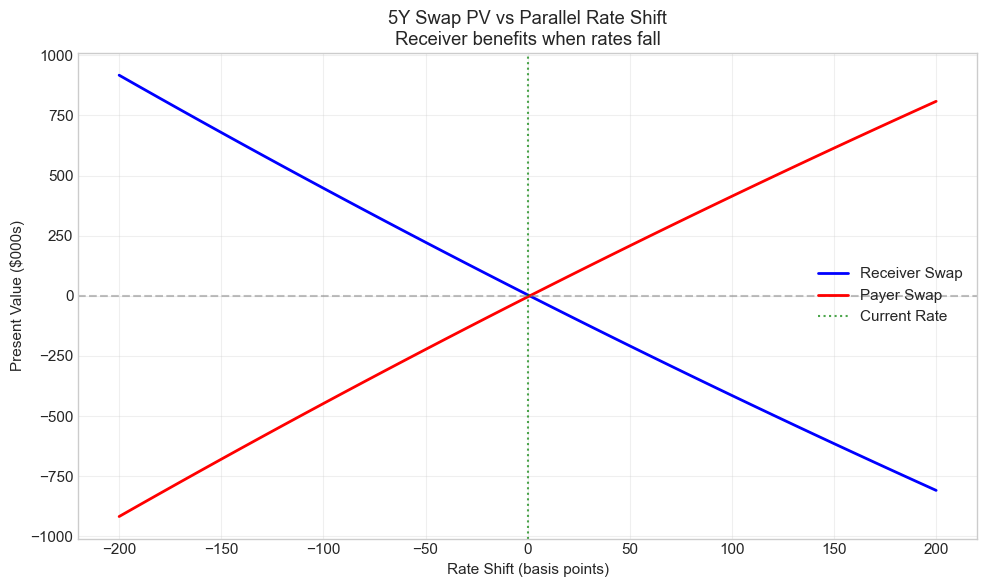

In [7]:
# How swap PV changes with parallel shift in rates
rate_shifts = np.linspace(-0.02, 0.02, 41)  # -200bp to +200bp
receiver_pvs = []
payer_pvs = []

base_rate = 0.05

for shift in rate_shifts:
    new_rate = base_rate + shift
    
    fixed_legs = []
    floating_legs = []
    
    for i in range(1, 6):
        df = np.exp(-new_rate * i)
        fwd = new_rate + 0.001 * (i - 3)
        
        fixed_legs.append(FixedLeg(
            start_time=i-1, end_time=i, accrual_factor=1.0,
            discount_factor=df, notional=notional, fixed_rate=fixed_rate,
        ))
        floating_legs.append(FloatingLeg(
            start_time=i-1, end_time=i, accrual_factor=1.0,
            discount_factor=df, notional=notional, forward_rate=fwd,
        ))
    
    # Receiver swap
    receiver = InterestRateSwapSimple(
        notional=notional, fixed_rate=fixed_rate,
        fixed_leg=tuple(fixed_legs), floating_leg=tuple(floating_legs),
        direction="receiver",
    )
    receiver_pvs.append(swap_pricer.price(receiver))
    
    # Payer swap
    payer = InterestRateSwapSimple(
        notional=notional, fixed_rate=fixed_rate,
        fixed_leg=tuple(fixed_legs), floating_leg=tuple(floating_legs),
        direction="payer",
    )
    payer_pvs.append(swap_pricer.price(payer))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rate_shifts * 10000, np.array(receiver_pvs) / 1000, 'b-', linewidth=2, label='Receiver Swap')
ax.plot(rate_shifts * 10000, np.array(payer_pvs) / 1000, 'r-', linewidth=2, label='Payer Swap')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='green', linestyle=':', alpha=0.7, label='Current Rate')
ax.set_xlabel('Rate Shift (basis points)')
ax.set_ylabel('Present Value ($000s)')
ax.set_title('5Y Swap PV vs Parallel Rate Shift\nReceiver benefits when rates fall')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 3: Caps and Floors

Caps and floors are portfolios of options on forward rates:
- **Caplet**: Call option on forward rate (max(L - K, 0))
- **Floorlet**: Put option on forward rate (max(K - L, 0))

Priced using Black76 model.

### 3.1 Caplet Pricing

In [8]:
# Create a caplet
caplet = CapletSimple(
    notional=10_000_000,
    strike=0.05,              # 5% strike
    fixing_time=1.0,          # 1 year to fixing
    payment_time=1.25,        # Payment 3 months later
    accrual_factor=0.25,      # Quarterly
    forward_rate=0.055,       # 5.5% forward (ITM)
    vol=0.20,                 # 20% lognormal vol
    discount_factor=0.95,
)

caplet_pricer = IrEuropeanCapletB76PricerSimple()
caplet_pv = caplet_pricer.price(caplet)
caplet_greeks = caplet_pricer.greeks(caplet)

print("Caplet Analysis (Black76)")
print("=" * 40)
print(f"Notional:      ${caplet.notional:,.0f}")
print(f"Strike:        {caplet.strike:.2%}")
print(f"Forward Rate:  {caplet.forward_rate:.2%}")
print(f"Volatility:    {caplet.vol:.1%}")
print()
print(f"Price:         ${caplet_pv:,.2f}")
print(f"Delta:         ${caplet_greeks['delta']:,.2f}")
print(f"Gamma:         ${caplet_greeks['gamma']:,.4f}")
print(f"Vega:          ${caplet_greeks['vega']:,.2f}")

Caplet Analysis (Black76)
Notional:      $10,000,000
Strike:        5.00%
Forward Rate:  5.50%
Volatility:    20.0%

Price:         $16,971.76
Delta:         $1,704,961.58
Gamma:         $72,945,562.2885
Vega:          $44,132.07


### 3.2 Caplet vs Floorlet (Put-Call Parity)

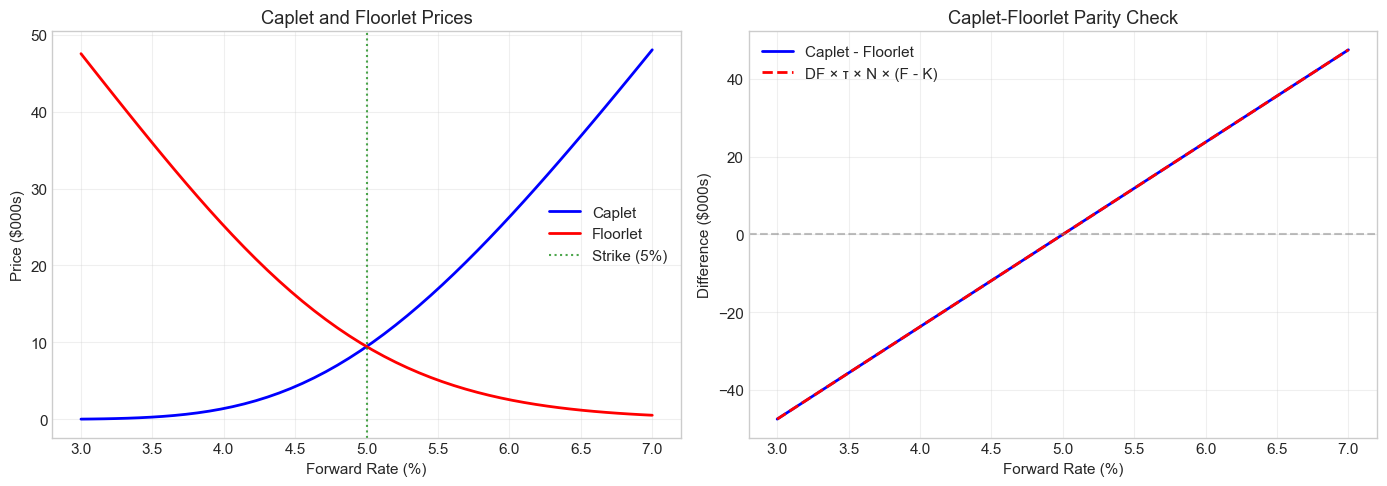

In [9]:
# Demonstrate caplet-floorlet parity
forward_rates = np.linspace(0.03, 0.07, 50)
caplet_pvs = []
floorlet_pvs = []

strike = 0.05
vol = 0.20
df = 0.95
tau = 0.25
N = 10_000_000

for fwd in forward_rates:
    cap = CapletSimple(
        notional=N, strike=strike, fixing_time=1.0, payment_time=1.25,
        accrual_factor=tau, forward_rate=fwd, vol=vol, discount_factor=df,
    )
    floor = FloorletSimple(
        notional=N, strike=strike, fixing_time=1.0, payment_time=1.25,
        accrual_factor=tau, forward_rate=fwd, vol=vol, discount_factor=df,
    )
    caplet_pvs.append(caplet_pricer.price(cap))
    floorlet_pvs.append(IrEuropeanFloorletB76PricerSimple().price(floor))

# Theoretical parity: Caplet - Floorlet = DF × τ × N × (F - K)
parity = df * tau * N * (forward_rates - strike)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Caplet and Floorlet prices
ax1.plot(forward_rates * 100, np.array(caplet_pvs) / 1000, 'b-', linewidth=2, label='Caplet')
ax1.plot(forward_rates * 100, np.array(floorlet_pvs) / 1000, 'r-', linewidth=2, label='Floorlet')
ax1.axvline(x=5.0, color='green', linestyle=':', alpha=0.7, label=f'Strike ({strike:.0%})')
ax1.set_xlabel('Forward Rate (%)')
ax1.set_ylabel('Price ($000s)')
ax1.set_title('Caplet and Floorlet Prices')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Put-call parity check
actual_diff = np.array(caplet_pvs) - np.array(floorlet_pvs)
ax2.plot(forward_rates * 100, actual_diff / 1000, 'b-', linewidth=2, label='Caplet - Floorlet')
ax2.plot(forward_rates * 100, parity / 1000, 'r--', linewidth=2, label='DF × τ × N × (F - K)')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Forward Rate (%)')
ax2.set_ylabel('Difference ($000s)')
ax2.set_title('Caplet-Floorlet Parity Check')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Cap Pricing (Multi-Period)

In [10]:
# Build a 2-year quarterly cap
caplets = []
strike = 0.05
vol = 0.20
N = 10_000_000

for i in range(8):  # 8 quarters
    fixing = 0.25 * (i + 1)  # 0.25, 0.50, ..., 2.0
    payment = fixing + 0.25
    df = np.exp(-0.05 * payment)
    fwd = 0.05 + 0.002 * np.sin(i)  # Some term structure
    
    caplets.append(CapletSimple(
        notional=N, strike=strike, fixing_time=fixing, payment_time=payment,
        accrual_factor=0.25, forward_rate=fwd, vol=vol, discount_factor=df,
    ))

cap = CapSimple(notional=N, strike=strike, caplets=tuple(caplets))
cap_pricer = IrEuropeanCapB76PricerSimple()

cap_pv = cap_pricer.price(cap)
cap_greeks = cap_pricer.greeks(cap)

print("2-Year Quarterly Cap Analysis")
print("=" * 40)
print(f"Notional:      ${N:,.0f}")
print(f"Strike:        {strike:.2%}")
print(f"Periods:       {len(caplets)} caplets")
print()
print(f"Total Premium: ${cap_pv:,.2f}")
print(f"Total Delta:   ${cap_greeks['delta']:,.2f}")
print(f"Total Vega:    ${cap_greeks['vega']:,.2f}")
print()
print("Individual Caplet PVs:")
for i, caplet in enumerate(caplets):
    cpv = caplet_pricer.price(caplet)
    print(f"  Caplet {i+1} (Fix={caplet.fixing_time:.2f}Y): ${cpv:,.2f}")

2-Year Quarterly Cap Analysis
Notional:      $10,000,000
Strike:        5.00%
Periods:       8 caplets

Total Premium: $77,249.22
Total Delta:   $10,299,150.07
Total Vega:    $370,960.86

Individual Caplet PVs:
  Caplet 1 (Fix=0.25Y): $4,861.63
  Caplet 2 (Fix=0.50Y): $9,115.51
  Caplet 3 (Fix=0.75Y): $10,694.09
  Caplet 4 (Fix=1.00Y): $9,715.22
  Caplet 5 (Fix=1.25Y): $8,507.51
  Caplet 6 (Fix=1.50Y): $8,891.76
  Caplet 7 (Fix=1.75Y): $11,215.53
  Caplet 8 (Fix=2.00Y): $14,247.96


---

## Part 4: Swaptions (Bachelier Model)

A swaption is an option to enter into a swap. Priced using Bachelier (normal) model for:
- Natural handling of negative rates
- Industry standard for EUR, JPY, CHF markets

### 4.1 Swaption Pricing

In [11]:
# 1Y into 5Y payer swaption (1Y5Y)
swaption = SwaptionSimple(
    notional=10_000_000,
    strike=0.04,              # 4% strike
    option_expiry=1.0,        # 1 year to expiry
    swap_tenor=5.0,           # 5 year underlying swap
    forward_swap_rate=0.042,  # 4.2% forward swap rate
    annuity=4.5,              # PV01 of underlying swap
    vol=0.0060,               # 60bp normal volatility
    discount_factor=0.95,
    swaption_type="payer",
)

swaption_pricer = IrEuropeanSwaptionBchPricerSimple()
swaption_pv = swaption_pricer.price(swaption)
swaption_greeks = swaption_pricer.greeks(swaption)
vega_bp = swaption_pricer.vega_bp(swaption)

print("1Y5Y Payer Swaption (Bachelier)")
print("=" * 45)
print(f"Notional:           ${swaption.notional:,.0f}")
print(f"Strike:             {swaption.strike:.2%}")
print(f"Forward Swap Rate:  {swaption.forward_swap_rate:.2%}")
print(f"Normal Vol:         {swaption.vol * 10000:.0f} bp")
print(f"Annuity:            {swaption.annuity:.4f}")
print(f"Tenor:              {swaption.tenor_description}")
print()
print(f"Premium:            ${swaption_pv:,.2f}")
print(f"Premium (% of N):   {swaption_pv / swaption.notional * 100:.3f}%")
print()
print("Greeks:")
print(f"  Delta:            ${swaption_greeks['delta']:,.2f}")
print(f"  Gamma:            ${swaption_greeks['gamma']:,.4f}")
print(f"  Vega (per 1bp):   ${vega_bp:,.2f}")

1Y5Y Payer Swaption (Bachelier)
Notional:           $10,000,000
Strike:             4.00%
Forward Swap Rate:  4.20%
Normal Vol:         60 bp
Annuity:            4.5000
Tenor:              1Y5Y

Premium:            $158,643.75
Premium (% of N):   1.586%

Greeks:
  Delta:            $28,375,139.69
  Gamma:            $2,830,374,207.6974
  Vega (per 1bp):   $1,698.22


### 4.2 Swaption Price vs Forward Swap Rate

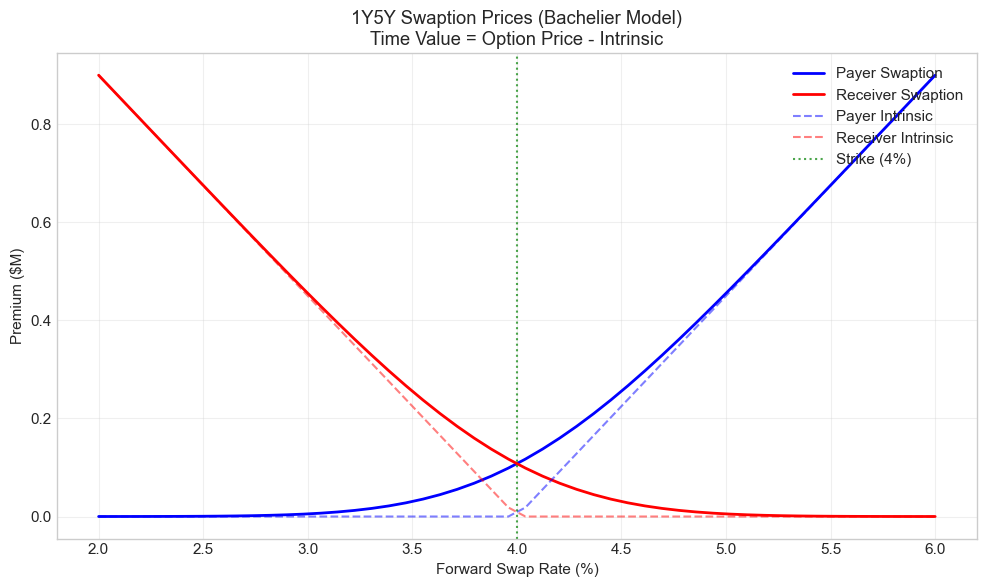

In [12]:
# Swaption price as function of forward rate
forward_rates = np.linspace(0.02, 0.06, 50)
payer_pvs = []
receiver_pvs = []

strike = 0.04
vol = 0.0060
annuity = 4.5
N = 10_000_000

for fwd in forward_rates:
    payer = SwaptionSimple(
        notional=N, strike=strike, option_expiry=1.0, swap_tenor=5.0,
        forward_swap_rate=fwd, annuity=annuity, vol=vol,
        discount_factor=0.95, swaption_type="payer",
    )
    receiver = SwaptionSimple(
        notional=N, strike=strike, option_expiry=1.0, swap_tenor=5.0,
        forward_swap_rate=fwd, annuity=annuity, vol=vol,
        discount_factor=0.95, swaption_type="receiver",
    )
    payer_pvs.append(swaption_pricer.price(payer))
    receiver_pvs.append(swaption_pricer.price(receiver))

# Intrinsic values
payer_intrinsic = N * annuity * np.maximum(forward_rates - strike, 0)
receiver_intrinsic = N * annuity * np.maximum(strike - forward_rates, 0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(forward_rates * 100, np.array(payer_pvs) / 1e6, 'b-', linewidth=2, label='Payer Swaption')
ax.plot(forward_rates * 100, np.array(receiver_pvs) / 1e6, 'r-', linewidth=2, label='Receiver Swaption')
ax.plot(forward_rates * 100, payer_intrinsic / 1e6, 'b--', alpha=0.5, label='Payer Intrinsic')
ax.plot(forward_rates * 100, receiver_intrinsic / 1e6, 'r--', alpha=0.5, label='Receiver Intrinsic')
ax.axvline(x=4.0, color='green', linestyle=':', alpha=0.7, label=f'Strike ({strike:.0%})')
ax.set_xlabel('Forward Swap Rate (%)')
ax.set_ylabel('Premium ($M)')
ax.set_title('1Y5Y Swaption Prices (Bachelier Model)\nTime Value = Option Price - Intrinsic')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Swaption Vega Surface

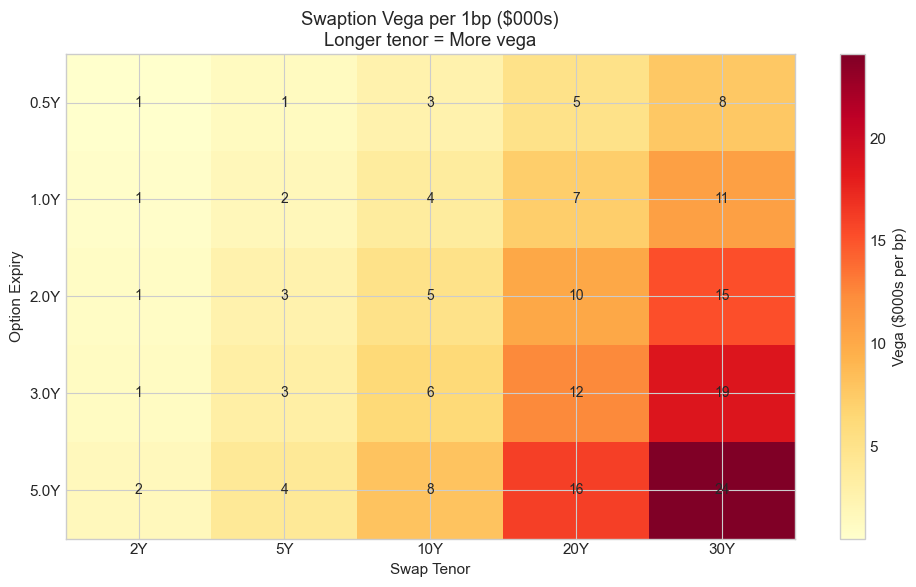

In [13]:
# Vega across expiries and tenors
expiries = [0.5, 1.0, 2.0, 3.0, 5.0]
tenors = [2, 5, 10, 20, 30]

vega_grid = np.zeros((len(expiries), len(tenors)))

for i, exp in enumerate(expiries):
    for j, tenor in enumerate(tenors):
        # Approximate annuity
        ann = tenor * 0.9  # Simplified
        df = np.exp(-0.04 * exp)
        
        sw = SwaptionSimple(
            notional=10_000_000,
            strike=0.04,
            option_expiry=exp,
            swap_tenor=tenor,
            forward_swap_rate=0.04,  # ATM
            annuity=ann,
            vol=0.0060,
            discount_factor=df,
            swaption_type="payer",
        )
        vega_grid[i, j] = swaption_pricer.vega_bp(sw) / 1000  # In $000s

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(vega_grid, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(tenors)))
ax.set_xticklabels([f'{t}Y' for t in tenors])
ax.set_yticks(range(len(expiries)))
ax.set_yticklabels([f'{e}Y' for e in expiries])
ax.set_xlabel('Swap Tenor')
ax.set_ylabel('Option Expiry')
ax.set_title('Swaption Vega per 1bp ($000s)\nLonger tenor = More vega')

# Add values to cells
for i in range(len(expiries)):
    for j in range(len(tenors)):
        ax.text(j, i, f'{vega_grid[i,j]:.0f}', ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax, label='Vega ($000s per bp)')
plt.tight_layout()
plt.show()

---

## Part 5: Model Comparison (Black76 vs Bachelier)

### 5.1 Price Comparison Near Zero Rates

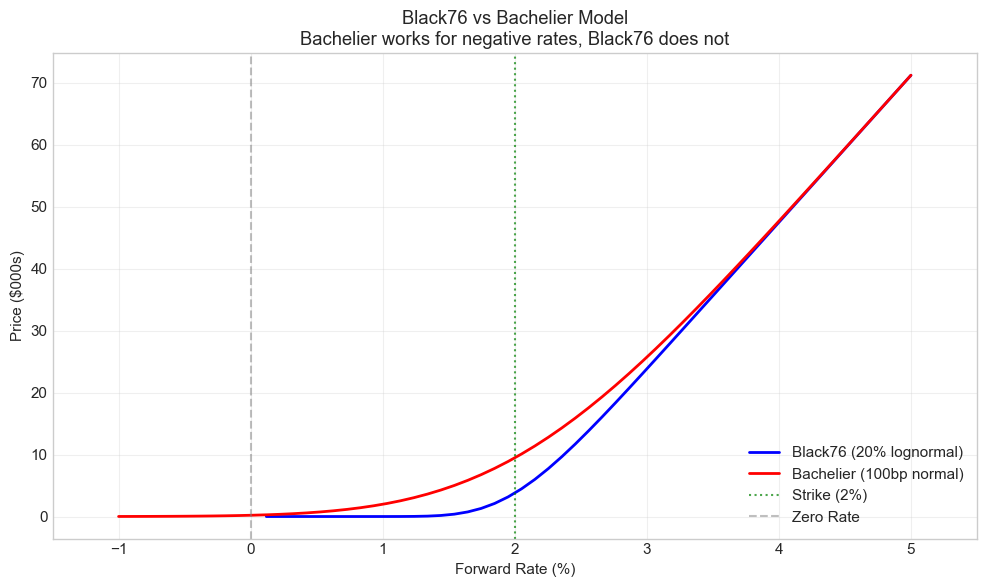

In [14]:
# Compare Black76 vs Bachelier for caplet near zero rates
# (Bachelier handles negative rates naturally)

forward_rates = np.linspace(-0.01, 0.05, 60)
strike = 0.02  # 2% strike
black_pvs = []
bachelier_pvs = []

# Lognormal vol for Black76, normal vol for Bachelier
# Approximate equivalence at 5% rate: 20% lognormal ≈ 100bp normal
black_vol = 0.20
bachelier_vol = 0.01  # 100bp

for fwd in forward_rates:
    if fwd > 0.001:  # Black76 needs positive forward
        cap_b76 = CapletSimple(
            notional=10_000_000, strike=strike, fixing_time=1.0, payment_time=1.25,
            accrual_factor=0.25, forward_rate=fwd, vol=black_vol, discount_factor=0.95,
        )
        black_pvs.append(caplet_pricer.price(cap_b76))
    else:
        black_pvs.append(np.nan)  # Black76 undefined
    
    # Bachelier works for any forward rate
    sw = SwaptionSimple(
        notional=10_000_000, strike=strike, option_expiry=1.0, swap_tenor=0.25,
        forward_swap_rate=fwd, annuity=0.25 * 0.95,  # τ × DF as proxy
        vol=bachelier_vol, discount_factor=0.95, swaption_type="payer",
    )
    bachelier_pvs.append(swaption_pricer.price(sw))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(forward_rates * 100, np.array(black_pvs) / 1000, 'b-', linewidth=2, label='Black76 (20% lognormal)')
ax.plot(forward_rates * 100, np.array(bachelier_pvs) / 1000, 'r-', linewidth=2, label='Bachelier (100bp normal)')
ax.axvline(x=strike * 100, color='green', linestyle=':', alpha=0.7, label=f'Strike ({strike:.0%})')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Zero Rate')
ax.set_xlabel('Forward Rate (%)')
ax.set_ylabel('Price ($000s)')
ax.set_title('Black76 vs Bachelier Model\nBachelier works for negative rates, Black76 does not')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.5, 5.5)
plt.tight_layout()
plt.show()

---

## Summary

This tutorial demonstrated QuantStrata's interest rate pricing capabilities:

| Instrument | Model | Key Features |
|------------|-------|-------------|
| FRA | Analytical | Linear payoff, DV01/delta |
| IRS | Analytical | Par rate, annuity, DV01 |
| Caps/Floors | Black76 | Option on forward rates, Greeks |
| Swaptions | Bachelier | Handles negative rates, normal vol |

### Key Takeaways

1. **Linear instruments** (FRA, IRS) have straightforward PV formulas based on forward rates and discount factors
2. **Options on rates** (caps/floors) are priced as portfolios of caplets/floorlets using Black76
3. **Swaptions** use Bachelier (normal) model which handles negative rates naturally
4. **DV01** is the key risk measure for linear products
5. **Vega** is the key risk measure for options